In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, Conv1D, BatchNormalization, Bidirectional, GRU, Dense, Dropout, GlobalAveragePooling1D, Multiply
from tensorflow.keras.models import Model

class MaxFeatureMap1D(Layer):
    """
    Max-Feature-Map (MFM) activation for 1D sequences.
    Splits the channel dimension in half and takes the element-wise maximum.
    """
    def __init__(self, **kwargs):
        super(MaxFeatureMap1D, self).__init__(**kwargs)

    def call(self, inputs):
        # inputs shape: (batch_size, time_steps, channels)
        channels = tf.shape(inputs)[-1]
        half_channels = channels // 2
        
        # Split into two tensors
        x1 = inputs[:, :, :half_channels]
        x2 = inputs[:, :, half_channels:]
        
        # Element-wise maximum
        return tf.maximum(x1, x2)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1], input_shape[2] // 2)

I0000 00:00:1775224850.567048  474194 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775224850.569096  474194 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775224850.704777  474194 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775224856.070656  474194 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
def build_lcnn_bigru_discriminator(seq_len=50, feature_dim=710):
    """
    Hybrid LCNN + BiGRU architecture for Audio Deepfake Detection.
    """
    inputs = Input(shape=(seq_len, feature_dim))

    # --- LCNN Block 1 ---
    # We output 256 channels because MFM will immediately halve it to 128
    x = Conv1D(256, kernel_size=3, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxFeatureMap1D()(x) 
    x = Dropout(0.3)(x)

    # --- LCNN Block 2 ---
    x = Conv1D(128, kernel_size=3, padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxFeatureMap1D()(x) # Halves to 64 channels
    x = Dropout(0.3)(x)

    # --- Temporal Coherence Block (BiGRU) ---
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    
    # --- Attention / Gating Mechanism ---
    attention_weights = Dense(1, activation='softmax')(x)
    context_vector = Multiply()([x, attention_weights])
    
    # --- Sequence to Vector ---
    x = GlobalAveragePooling1D()(context_vector)

    # --- Classification Head ---
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.4)(x)
    
    # Sigmoid for Real (0.0) vs Fake (1.0)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name="DeepCheck_LCNN_BiGRU")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Instantiate and check parameters
model = build_lcnn_bigru_discriminator()
model.summary()

E0000 00:00:1775224859.654395  474194 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "DeepCheck_LCNN_BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50, 710)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 50, 256)   │    545,536 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 256)   │      1,024 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_feature_map1d   │ (None, 50, 128)   │          0 │ batch_normalizat… │
│ (MaxFeatureMap1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50, 128)   │          0 │ max_feature_map1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 50, 128)   │     49,280 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_feature_map1d_1 │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (MaxFeatureMap1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50, 64)    │          0 │ max_feature_map1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 50, 128)   │     49,920 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 1)     │        129 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 50, 128)   │          0 │ bidirectional[0]… │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      4,128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 650,562 (2.48 MB)

 Trainable params: 649,794 (2.48 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
import os
import numpy as np
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf
from feature_extractor import process_audio_file # Your module from Phase 2

# Constants
DATA_DIR = Path('training_data')
CACHE_DIR = Path('feature_cache')
CACHE_DIR.mkdir(exist_ok=True)

def crawl_and_cache_dataset(data_dir, cache_dir):
    """
    Crawls the directory structure, runs the 142-dim + context extraction,
    and saves the output as fast-loading .npy files.
    """
    labels = {'real': 0.0, 'fake': 1.0}
    dataset_index = []
    
    print("Initiating Forensic Feature Pre-computation...")
    
    for class_name, label in labels.items():
        class_path = data_dir / class_name
        # Find all .wav files in subdirectories (english/hindi)
        wav_files = list(class_path.rglob('*.wav'))
        
        for wav_path in tqdm(wav_files, desc=f"Processing {class_name.upper()}"):
            try:
                # 1. Extract 710-dim Contextualized Tensor
                feature_tensor = process_audio_file(str(wav_path))
                
                # 2. Save to cache
                save_name = f"{class_name}_{wav_path.stem}.npy"
                save_path = cache_dir / save_name
                np.save(save_path, feature_tensor)
                
                # 3. Log into index
                dataset_index.append({
                    'path': str(save_path),
                    'label': label
                })
            except Exception as e:
                print(f"Failed to process {wav_path.name}: {e}")
                
    return dataset_index

# Run this ONCE. It may take an hour, but will save days of training time.
dataset_index = crawl_and_cache_dataset(DATA_DIR, CACHE_DIR)
print(f"\nSuccessfully cached {len(dataset_index)} audio files.")

import json

INDEX_PATH = CACHE_DIR / 'dataset_index.json'

# --- UPDATE YOUR BLOCK 3 RUN LOGIC TO THIS ---
if INDEX_PATH.exists():
    print("Loading pre-computed dataset index from disk...")
    with open(INDEX_PATH, 'r') as f:
        dataset_index = json.load(f)
else:
    # Run the hour-long extraction
    dataset_index = crawl_and_cache_dataset(DATA_DIR, CACHE_DIR)
    
    # Save the index to disk for future use
    with open(INDEX_PATH, 'w') as f:
        json.dump(dataset_index, f)
        
print(f"\nSuccessfully loaded {len(dataset_index)} audio profiles.")

In [ ]:
import numpy as np
import random

def verify_cache_integrity(index_list, sample_ratio=0.1):
    """
    Randomly samples the extracted .npy files to ensure dimensional accuracy
    and check for fatal NaN/Inf values that would crash the neural network.
    """
    sample_size = max(1, int(len(index_list) * sample_ratio))
    sampled_items = random.sample(index_list, sample_size)
    
    print(f"--- Initiating Tensor Integrity Check on {sample_size} Files ---\n")
    
    fatal_errors = 0
    shape_errors = 0
    
    for item in sampled_items:
        try:
            tensor = np.load(item['path'])
            
            # 1. Dimensionality Check
            if len(tensor.shape) != 2 or tensor.shape[1] != 710:
                print(f"[SHAPE ERROR] {item['path']} has shape {tensor.shape}. Expected (T, 710).")
                shape_errors += 1
                
            # 2. Mathematical Stability Check (NaNs and Infs)
            if np.isnan(tensor).any():
                print(f"[FATAL: NaN] {item['path']} contains NaN values.")
                fatal_errors += 1
            if np.isinf(tensor).any():
                print(f"[FATAL: Inf] {item['path']} contains Infinity values.")
                fatal_errors += 1
                
        except Exception as e:
            print(f"[LOAD ERROR] Could not read {item['path']}: {e}")
            fatal_errors += 1
            
    # Final Report
    print(f"Check Complete.")
    if fatal_errors == 0 and shape_errors == 0:
        print("SUCCESS: All tested tensors are dimensionally stable and mathematically clean.")
        print("You are cleared to proceed to model.fit().")
    else:
        print(f"WARNING: Found {fatal_errors} fatal corruptions and {shape_errors} shape mismatches.")
        print("Do NOT run training until these specific files are deleted or fixed.")

# Run the verification on 10% of your dataset
verify_cache_integrity(dataset_index, sample_ratio=0.10)

In [ ]:
from sklearn.model_selection import train_test_split

class AudioForensicGenerator(tf.keras.utils.Sequence):
    def __init__(self, data_index, batch_size=32, max_seq_len=300, feature_dim=710):
        self.data_index = data_index
        self.batch_size = batch_size
        self.max_seq_len = max_seq_len
        self.feature_dim = feature_dim
        self.indices = np.arange(len(self.data_index))
        np.random.shuffle(self.indices)
        
    def __len__(self):
        return int(np.ceil(len(self.data_index) / self.batch_size))
        
    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        
        X_batch = np.zeros((len(batch_indices), self.max_seq_len, self.feature_dim), dtype=np.float32)
        Y_batch = np.zeros((len(batch_indices), 1), dtype=np.float32)
        
        for i, idx in enumerate(batch_indices):
            item = self.data_index[idx]
            features = np.load(item['path'])
            
            # Temporal Truncation / Padding
            t_frames = features.shape[0]
            if t_frames >= self.max_seq_len:
                # Truncate strictly to max_seq_len
                X_batch[i] = features[:self.max_seq_len, :]
            else:
                # Zero-pad if shorter
                X_batch[i, :t_frames, :] = features
                
            Y_batch[i, 0] = item['label']
            
        return X_batch, Y_batch
        
    def on_epoch_end(self):
        np.random.shuffle(self.indices)

# Split dataset 80/20 for Training and Validation
train_idx, val_idx = train_test_split(dataset_index, test_size=0.2, random_state=42, stratify=[d['label'] for d in dataset_index])

train_gen = AudioForensicGenerator(train_idx)
val_gen = AudioForensicGenerator(val_idx)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Compile the Hybrid LCNN-BiGRU
model = build_lcnn_bigru_discriminator(seq_len=300, feature_dim=710)

callbacks = [
    ModelCheckpoint('deepcheck_best_model.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# Execute Training
print("Initiating LCNN-BiGRU Training Matrix...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
    # Removed 'workers' and 'use_multiprocessing' to comply with Keras 3
)

--- Initiating ASVspoof 2019 Blind Evaluation ---
Successfully loaded 'deepcheck_best_model.keras'
Found 24844 files in ASVspoof Dev protocol.
Subsampling to 1000 files for rapid testing...

Starting Extraction and Inference...


  0%|          | 0/1000 [00:00<?, ?it/s]/home/tech_adnan/noise_project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tech_adnan/noise_project/NOISE_CANCELLATION/Deepfake_project/feature_extractor.py:195: UserWarning: With fmin=100.000, sr=16000 and frame_length=320, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=100.000 or frame_length=321.
  f0 = librosa.yin(
/home/tech_adnan/noise_project/.venv/lib/python3.10/site-packages/keras/src/ops/nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 300, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
100%|██████████|


--- Evaluation Results ---
F1 Score (Threshold 0.5): 0.9455
Equal Error Rate (EER):   32.61%
Optimal EER Threshold:    0.9999


<Figure size 800x600 with 0 Axes>

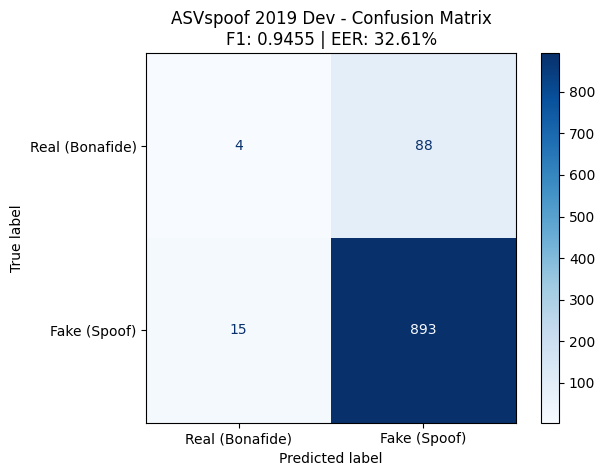

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Layer
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay

from feature_extractor import process_audio_file  # Your module from Phase 2

# ==========================================
# 1. CUSTOM LAYER DEFINITION (REQUIRED FOR LOADING)
# ==========================================
class MaxFeatureMap1D(Layer):
    """
    Max-Feature-Map (MFM) activation for 1D sequences.
    Splits the channel dimension in half and takes the element-wise maximum.
    """
    def __init__(self, **kwargs):
        super(MaxFeatureMap1D, self).__init__(**kwargs)

    def call(self, inputs):
        channels = tf.shape(inputs)[-1]
        half_channels = channels // 2
        x1 = inputs[:, :, :half_channels]
        x2 = inputs[:, :, half_channels:]
        return tf.maximum(x1, x2)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1], input_shape[2] // 2)

# ==========================================
# 2. PATH CONFIGURATION
# ==========================================
PROTOCOL_FILE = Path("la/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt")
AUDIO_DIR = Path("la/ASVspoof2019_LA_dev/flac")
MODEL_PATH = "MOdel1.0.keras"

MAX_TEST_FILES = 1000 
SEQ_LEN = 300
FEATURE_DIM = 710

def evaluate_on_asvspoof():
    print("--- Initiating ASVspoof 2019 Blind Evaluation ---")
    
    # 3. Load the Model with Custom Objects
    try:
        model = tf.keras.models.load_model(
            MODEL_PATH, 
            custom_objects={'MaxFeatureMap1D': MaxFeatureMap1D}
        )
        print("Successfully loaded 'deepcheck_best_model.keras'")
    except Exception as e:
        print(f"Error loading model: {e}")
        return

    # 4. Parse the Protocol File
    if not PROTOCOL_FILE.exists():
        print(f"Cannot find protocol file at: {PROTOCOL_FILE}")
        return
        
    y_true = []
    audio_paths = []
    
    with open(PROTOCOL_FILE, 'r') as f:
        lines = f.readlines()
        
    print(f"Found {len(lines)} files in ASVspoof Dev protocol.")
    
    if MAX_TEST_FILES:
        # Shuffle to ensure a mix of real/fake if subsetting
        np.random.seed(42)
        np.random.shuffle(lines)
        lines = lines[:MAX_TEST_FILES]
        print(f"Subsampling to {MAX_TEST_FILES} files for rapid testing...")

    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            file_id = parts[1]
            label = parts[4]  # 'bonafide' or 'spoof'
            
            flac_path = AUDIO_DIR / f"{file_id}.flac"
            
            if flac_path.exists():
                audio_paths.append(flac_path)
                y_true.append(0.0 if label == 'bonafide' else 1.0)
            else:
                print(f"Warning: Missing audio file {flac_path}")

    # 5. Feature Extraction and Inference Loop
    y_pred_probs = []
    y_true_clean = [] # Only keep labels for files that successfully extracted
    
    print("\nStarting Extraction and Inference...")
    for i, path in enumerate(tqdm(audio_paths)):
        try:
            # Extract 2D Feature Tensor
            features = process_audio_file(str(path))
            
            # Truncate or Zero-pad to strict Sequence Length
            X_input = np.zeros((1, SEQ_LEN, FEATURE_DIM), dtype=np.float32)
            t_frames = features.shape[0]
            
            if t_frames >= SEQ_LEN:
                X_input[0] = features[:SEQ_LEN, :]
            else:
                X_input[0, :t_frames, :] = features
                
            # Predict Probability
            prob = model.predict(X_input, verbose=0)[0][0]
            y_pred_probs.append(prob)
            y_true_clean.append(y_true[i])
            
        except Exception as e:
            pass # Skip corrupted audio files if any exist

    y_true_clean = np.array(y_true_clean)
    y_pred_probs = np.array(y_pred_probs)
    
    # Standard threshold at 0.5
    y_pred_binary = (y_pred_probs > 0.5).astype(float)

    # ==========================================
    # 6. METRICS CALCULATION
    # ==========================================
    print("\n--- Evaluation Results ---")
    
    # A. F1 Score
    f1 = f1_score(y_true_clean, y_pred_binary)
    print(f"F1 Score (Threshold 0.5): {f1:.4f}")
    
    # B. Equal Error Rate (EER) - The ASVspoof Standard
    fpr, tpr, thresholds = roc_curve(y_true_clean, y_pred_probs)
    fnr = 1 - tpr
    # Find the threshold where FPR == FNR
    eer_index = np.nanargmin(np.absolute(fnr - fpr))
    eer = fpr[eer_index]
    optimal_threshold = thresholds[eer_index]
    print(f"Equal Error Rate (EER):   {eer*100:.2f}%")
    print(f"Optimal EER Threshold:    {optimal_threshold:.4f}")

    # C. Confusion Matrix
    cm = confusion_matrix(y_true_clean, y_pred_binary)
    
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real (Bonafide)', 'Fake (Spoof)'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"ASVspoof 2019 Dev - Confusion Matrix\nF1: {f1:.4f} | EER: {eer*100:.2f}%")
    plt.show()

# Execute the evaluation
evaluate_on_asvspoof()

In [5]:
DEV_PROTOCOL = Path("la/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt")
DEV_AUDIO_DIR = Path("la/ASVspoof2019_LA_dev/flac")

--- Initiating Balanced ASVspoof 2019 Dev Evaluation (1000 per class) ---
Sampled exactly 1000 Real and 1000 Fake files for a perfectly balanced test.


Extracting & Predicting:   0%|          | 0/2000 [00:00<?, ?it/s]/home/tech_adnan/noise_project/NOISE_CANCELLATION/Deepfake_project/feature_extractor.py:195: UserWarning: With fmin=100.000, sr=16000 and frame_length=320, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=100.000 or frame_length=321.
  f0 = librosa.yin(
/home/tech_adnan/noise_project/.venv/lib/python3.10/site-packages/keras/src/ops/nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 300, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
Extracting & Predicting: 100%|██████████| 2000/2000 [05:31<00:00,  6.03it/s]



--- Balanced Results ---
F1 Score (Threshold 0.5): 0.6751
Equal Error Rate (EER):   33.80%
Optimal EER Threshold:    0.9999


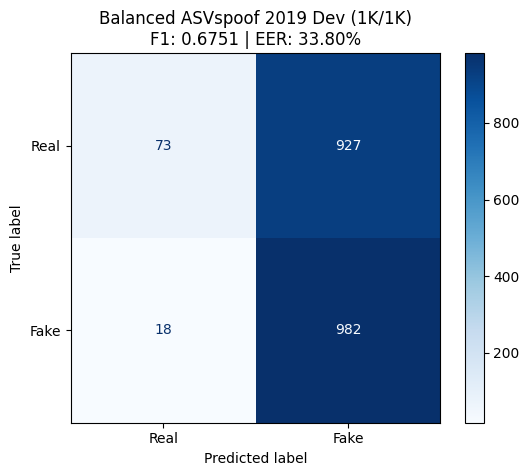

In [6]:
# 8. BALANCED BLIND EVALUATION (ASVSPOOF DEV SET)
import random

def evaluate_balanced_asvspoof(samples_per_class=1000):
    print(f"--- Initiating Balanced ASVspoof 2019 Dev Evaluation ({samples_per_class} per class) ---")
    
    # 1. Load Model
    try:
        model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'MaxFeatureMap1D': MaxFeatureMap1D})
    except Exception as e:
        print(f"Failed to load model: {e}"); return
        
    # 2. Parse Protocol and Separate Classes
    with open(DEV_PROTOCOL, 'r') as f: 
        lines = f.readlines()
        
    reals = []
    fakes = []
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            if parts[4] == 'bonafide':
                reals.append(line)
            else:
                fakes.append(line)
                
    # 3. Shuffle and Sample Exactly 50/50
    random.seed(42)
    random.shuffle(reals)
    random.shuffle(fakes)
    
    # Prevent out-of-bounds errors if requesting more files than exist
    n_reals = min(samples_per_class, len(reals))
    n_fakes = min(samples_per_class, len(fakes))
    
    balanced_lines = reals[:n_reals] + fakes[:n_fakes]
    random.shuffle(balanced_lines) # Mix them up for the inference loop
    
    print(f"Sampled exactly {n_reals} Real and {n_fakes} Fake files for a perfectly balanced test.")
        
    # 4. Map Paths
    y_true, audio_paths = [], []
    for line in balanced_lines:
        parts = line.strip().split()
        flac_path = DEV_AUDIO_DIR / f"{parts[1]}.flac"
        if flac_path.exists():
            audio_paths.append(flac_path)
            y_true.append(0.0 if parts[4] == 'bonafide' else 1.0)

    # 5. Extraction & Inference Loop
    y_pred_probs, y_true_clean = [], []
    for i, path in enumerate(tqdm(audio_paths, desc="Extracting & Predicting")):
        try:
            features = process_audio_file(str(path))
            X_input = np.zeros((1, SEQ_LEN, FEATURE_DIM), dtype=np.float32)
            t_frames = features.shape[0]
            
            if t_frames >= SEQ_LEN: X_input[0] = features[:SEQ_LEN, :]
            else: X_input[0, :t_frames, :] = features
                
            y_pred_probs.append(model.predict(X_input, verbose=0)[0][0])
            y_true_clean.append(y_true[i])
        except: pass

    y_true_clean = np.array(y_true_clean)
    y_pred_probs = np.array(y_pred_probs)
    
    # Base threshold at 0.5
    y_pred_binary = (y_pred_probs > 0.5).astype(float)

    # 6. Metrics Calculation
    fpr, tpr, thresholds = roc_curve(y_true_clean, y_pred_probs)
    eer_index = np.nanargmin(np.absolute((1 - tpr) - fpr))
    eer = fpr[eer_index]
    
    f1 = f1_score(y_true_clean, y_pred_binary)
    
    print("\n--- Balanced Results ---")
    print(f"F1 Score (Threshold 0.5): {f1:.4f}")
    print(f"Equal Error Rate (EER):   {eer*100:.2f}%")
    print(f"Optimal EER Threshold:    {thresholds[eer_index]:.4f}")

    # 7. Confusion Matrix Plot
    cm = confusion_matrix(y_true_clean, y_pred_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Balanced ASVspoof 2019 Dev (1K/1K)\nF1: {f1:.4f} | EER: {eer*100:.2f}%")
    plt.show()

# Execute the perfectly balanced evaluation
evaluate_balanced_asvspoof(samples_per_class=1000)